# Brain Tumor MRI Classification — EfficientNetB0 Transfer Learning (Baseline)

**Dataset:** Brain Tumor MRI Dataset (Masoud Nickparvar)
Path used on Kaggle: `/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset`

Classes: `glioma`, `meningioma`, `notumor`, `pituitary`

This notebook is one of the CNN **baselines** (Task 2) that the graph-based
model will later be compared against. It builds an EfficientNetB0 transfer
learning classifier using a `tf.data` input pipeline (image loading, resizing,
EfficientNet-specific normalization, on-the-fly augmentation via Keras
preprocessing layers, and class-imbalance handling), then reports the full
evaluation suite needed for a fair CNN-vs-GCN comparison: accuracy curves,
confusion matrices, classification report, model size and inference latency.

**Pipeline**
1. Setup & config
2. Index dataset files (train / val / test) + duplicate-leakage audit
3. `tf.data` pipeline: decode, resize, EfficientNet preprocessing, augmentation
4. Class-imbalance handling (class weights)
5. Model: EfficientNetB0 backbone + custom head
6. Phase 1 — train head (frozen backbone), min 50 / max 100 epochs, patience 6
7. Phase 2 — fine-tune top backbone blocks, min 50 / max 100 epochs, patience 6
8. Evaluation: curves, confusion matrix, classification report
9. Baseline metrics summary: accuracy/precision/recall/F1, model size, inference time
10. Prediction gallery (correct & misclassified)
11. Save the final model


## 1. Setup & Configuration

In [1]:
import os
import time
import json
import hashlib
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score,
)

sns.set_style("darkgrid")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
DATA_DIR = pathlib.Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

CLASS_NAMES = sorted(["glioma", "meningioma", "notumor", "pituitary"])
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

IMG_SIZE = 224                # EfficientNetB0's native input resolution
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE = 32

# --- Epoch / early-stopping policy (per assignment spec) ---
# Each phase trains for at least MIN_EPOCHS before EarlyStopping is armed
# (`start_from_epoch`), then stops after PATIENCE epochs without a val_loss
# improvement, restoring the best-val_loss weights. MAX_EPOCHS is a hard
# ceiling so a run always terminates.
MIN_EPOCHS = 50
MAX_EPOCHS = 100
PATIENCE = 6

_tf_ver = tuple(int(p) for p in tf.__version__.split(".")[:2])
assert _tf_ver >= (2, 11), (
    f"TensorFlow {tf.__version__} does not support EarlyStopping(start_from_epoch=...); "
    "please use TF>=2.11 on Kaggle (Settings > Environment)."
)


## 2. Index the Dataset

Every file is catalogued with its class label and split. The official
`Testing` folder is divided into a validation set (used for early stopping /
model selection) and a held-out test set (touched only for final reporting),
mirroring the split strategy used in the EDA notebook.

In [3]:
def list_files(root: pathlib.Path, split_name: str) -> pd.DataFrame:
    rows = []
    for cls in CLASS_NAMES:
        for img_path in sorted((root / cls).iterdir()):
            if img_path.is_file():
                rows.append({"filepath": str(img_path), "label": cls, "split": split_name})
    return pd.DataFrame(rows)

train_pool = list_files(TRAIN_DIR, "train")
holdout_pool = list_files(TEST_DIR, "test")

print(f"Training pool : {len(train_pool):5d} images")
print(f"Testing pool  : {len(holdout_pool):5d} images")
train_pool.head()


Training pool :  5600 images
Testing pool  :  1600 images


,filepath,label,split
0,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,train
1,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,train
2,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,train
3,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,train
4,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,train


In [4]:
# Carve the official Testing folder into validation + final test (stratified 50/50)
val_df, test_df = train_test_split(
    holdout_pool, test_size=0.5, stratify=holdout_pool["label"], random_state=SEED
)
train_df = train_pool.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"train: {len(train_df)}  |  val: {len(val_df)}  |  test: {len(test_df)}")
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = split_df["label"].value_counts().reindex(CLASS_NAMES)
    print(f"\n{split_name} distribution:\n{counts}")


train: 5600  |  val: 800  |  test: 800

train distribution:
label
glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Name: count, dtype: int64

val distribution:
label
glioma        200
meningioma    200
notumor       200
pituitary     200
Name: count, dtype: int64

test distribution:
label
glioma        200
meningioma    200
notumor       200
pituitary     200
Name: count, dtype: int64


### 2b. Cross-Split Duplicate Audit

The public MRI dataset is known to contain exact and near-duplicate slices
(e.g. the same scan saved/cropped multiple times, or adjacent slices from the
same patient/study). If a duplicate of a training image leaks into
validation/test, evaluation metrics become overly optimistic. Two checks are
run, matching the approach used in the VGG16 baseline notebook so leakage is
handled consistently across all CNN baselines:

1. **Exact duplicates** — identical file bytes (MD5 hash).
2. **Near duplicates** — a perceptual / average hash (16x16 = 256-bit). A
   smaller 8x8/64-bit hash was tried first but collides on
   visually-similar-but-different MRI slices far too often on this dataset
   (~37% class-mismatch rate when checked against ground-truth labels) — it
   was mostly flagging unrelated images, not finding real duplicates. The
   16x16 hash is paired with an explicit **class-mismatch check**: a "near
   duplicate" whose label doesn't match the train image it collided with is
   treated as a hash false positive and is kept, not dropped.

Any overlap found between `train` and `val`/`test` is removed from the
evaluation splits (never from train). We also check `val` against `test`
directly (both come from splitting the original `Testing/` folder in half,
so this should be zero by construction) and remove any exact duplicates
found there from `test`.

In [5]:
def md5_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def average_hash(filepath, hash_size=16):
    """Perceptual hash: resize to (hash_size x hash_size) grayscale,
    threshold against the mean pixel value. Robust to re-saves/re-compression,
    unlike MD5. hash_size=16 (256-bit hash) is used instead of the smaller
    8x8/64-bit hash -- on this dataset the 8x8 hash was found to collide on
    visually-similar-but-different MRI slices at a high rate (~37% class
    mismatch when checked against ground-truth labels), so it was flagging
    mostly unrelated images as "near duplicates," not real leakage. The larger
    hash is far less prone to this. We still don't trust it blindly -- see the
    class-mismatch check below.
    """
    img = Image.open(filepath).convert("L").resize((hash_size, hash_size), Image.LANCZOS)
    pixels = np.asarray(img, dtype=np.float32)
    avg = pixels.mean()
    bits = (pixels > avg).flatten()
    return "".join("1" if b else "0" for b in bits)

def build_hash_table(df, md5_col="md5", phash_col="phash"):
    df = df.copy()
    df[md5_col] = df["filepath"].apply(md5_hash)
    df[phash_col] = df["filepath"].apply(average_hash)
    return df

print("Hashing images (this scans every file once)...")
train_hashed = build_hash_table(train_df)
val_hashed = build_hash_table(val_df)
test_hashed = build_hash_table(test_df)

def report_overlap(name_a, df_a, name_b, df_b, col, label):
    set_a = set(df_a[col])
    overlap = df_b[df_b[col].isin(set_a)]
    print(f"{label} overlap {name_a} -> {name_b}: {len(overlap)} of {len(df_b)} {name_b} images")
    return overlap

def report_near_overlap_with_class_check(name_a, df_a, name_b, df_b, col="phash"):
    """Like report_overlap, but for the perceptual hash we additionally check
    whether the flagged pair actually shares a class label. A hash collision
    between e.g. a glioma slice and a notumor slice can't be a real duplicate
    -- it's a false positive from the hash, and should NOT be dropped. Only
    class-matched collisions are treated as genuine near-duplicate leakage.
    """
    hash_to_classes = df_a.groupby(col)["label"].agg(lambda s: set(s))
    overlap = df_b[df_b[col].isin(set(df_a[col]))].copy()

    # Guard against the empty-overlap case: `.apply(..., axis=1)` on a
    # zero-row frame returns the frame itself (not a Series), so assigning
    # its result to a single column below would raise a ValueError. Zero
    # near-duplicates is a perfectly normal outcome (e.g. for a well-cleaned
    # test split), so handle it explicitly instead of letting it crash.
    if overlap.empty:
        overlap["train_classes"] = pd.Series(dtype=object)
        overlap["class_match"] = pd.Series(dtype=bool)
        print(f"Near overlap {name_a} -> {name_b}: 0 of {len(df_b)} {name_b} images")
        return overlap[overlap["class_match"]]

    overlap["train_classes"] = overlap[col].map(lambda h: hash_to_classes.get(h, set()))
    overlap["class_match"] = overlap.apply(lambda r: r["label"] in r["train_classes"], axis=1)

    n_total = len(overlap)
    n_match = int(overlap["class_match"].sum())
    n_mismatch = n_total - n_match
    print(f"Near overlap {name_a} -> {name_b}: {n_total} of {len(df_b)} {name_b} images "
          f"({n_total/len(df_b):.1%})")
    if n_total:
        print(f"  of which class-matched (treated as real leakage): {n_match} "
              f"({n_match/n_total:.1%})")
        print(f"  of which class-mismatched (hash false positives, kept): {n_mismatch} "
              f"({n_mismatch/n_total:.1%})")
    return overlap[overlap["class_match"]]

print("\n--- Exact duplicates (MD5) ---")
dup_val_md5 = report_overlap("train", train_hashed, "val", val_hashed, "md5", "Exact")
dup_test_md5 = report_overlap("train", train_hashed, "test", test_hashed, "md5", "Exact")

print("\n--- Near duplicates (average hash, 16x16, class-mismatch checked) ---")
dup_val_phash = report_near_overlap_with_class_check("train", train_hashed, "val", val_hashed)
dup_test_phash = report_near_overlap_with_class_check("train", train_hashed, "test", test_hashed)

# val <-> test leakage check. Both splits come from dividing the original
# Testing/ folder in half, so any overlap here is a real bug (not expected
# duplicate MRI slices). We remove val<->test duplicates from `test`,
# keeping `val` intact, since val is already being treated as fixed relative
# to train above.
print("\n--- val <-> test (should be 0 by construction) ---")
dup_valtest_md5 = report_overlap("val", val_hashed, "test", test_hashed, "md5", "Exact")

# Drop leaked rows from val/test (never touch train -- train is the source of truth)
leak_val_idx = set(dup_val_md5.index) | set(dup_val_phash.index)
leak_test_idx = set(dup_test_md5.index) | set(dup_test_phash.index) | set(dup_valtest_md5.index)

if leak_val_idx or leak_test_idx:
    print(f"\nDropping {len(leak_val_idx)} leaked rows from val, {len(leak_test_idx)} from test "
          f"(of which {len(dup_valtest_md5.index)} are val<->test duplicates removed from test).")
    val_df = val_hashed.drop(index=leak_val_idx).drop(columns=["md5", "phash"]).reset_index(drop=True)
    test_df = test_hashed.drop(index=leak_test_idx).drop(columns=["md5", "phash"]).reset_index(drop=True)
else:
    print("\nNo leakage detected. Splits are clean.")

print("\nFinal split sizes after leakage removal:")
print(f"train: {len(train_df)}  |  val: {len(val_df)}  |  test: {len(test_df)}")


Hashing images (this scans every file once)...

--- Exact duplicates (MD5) ---
Exact overlap train -> val: 0 of 800 val images
Exact overlap train -> test: 0 of 800 test images

--- Near duplicates (average hash, 16x16, class-mismatch checked) ---
Near overlap train -> val: 181 of 800 val images (22.6%)
  of which class-matched (treated as real leakage): 180 (99.4%)
  of which class-mismatched (hash false positives, kept): 1 (0.6%)
Near overlap train -> test: 188 of 800 test images (23.5%)
  of which class-matched (treated as real leakage): 185 (98.4%)
  of which class-mismatched (hash false positives, kept): 3 (1.6%)

--- val <-> test (should be 0 by construction) ---
Exact overlap val -> test: 7 of 800 test images

Dropping 180 leaked rows from val, 191 from test (of which 7 are val<->test duplicates removed from test).

Final split sizes after leakage removal:
train: 5600  |  val: 620  |  test: 609


## 3. `tf.data` Input Pipeline

Rather than `ImageDataGenerator`, images are loaded through `tf.data`:
files are read and decoded with `tf.io`, resized to EfficientNetB0's native
224×224 input, and passed through
`tensorflow.keras.applications.efficientnet.preprocess_input` (EfficientNet
expects raw 0–255 RGB pixels — its normalization is baked into the first
layer of the network, so `preprocess_input` here is effectively an identity
pass-through, but we call it explicitly to stay correct if the backbone
changes). Augmentation is implemented with Keras preprocessing layers
(`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomContrast`,
`RandomTranslation`) applied only to the training split, inside a
`tf.function`-mapped pipeline for speed.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

def decode_and_resize(filepath, label_idx):
    raw = tf.io.read_file(filepath)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label_idx

def make_dataset(df: pd.DataFrame, training: bool) -> tf.data.Dataset:
    filepaths = df["filepath"].values
    labels = df["label"].map(CLASS_TO_IDX).values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(lambda x, y: (augmenter(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (effnet_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# One-hot targets for compatibility with categorical_crossentropy / softmax head
def to_one_hot(x, y):
    return x, tf.one_hot(y, NUM_CLASSES)

train_ds_oh = train_ds.map(to_one_hot, num_parallel_calls=AUTOTUNE)
val_ds_oh = val_ds.map(to_one_hot, num_parallel_calls=AUTOTUNE)
test_ds_oh = test_ds.map(to_one_hot, num_parallel_calls=AUTOTUNE)

for batch_x, batch_y in train_ds_oh.take(1):
    print("Batch image shape:", batch_x.shape, "| Batch label shape:", batch_y.shape)
    print("Pixel value range after preprocessing:", float(tf.reduce_min(batch_x)), "to", float(tf.reduce_max(batch_x)))


I0000 00:00:1787160993.178709      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787160993.182032      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Batch image shape: (32, 224, 224, 3) | Batch label shape: (32, 4)
Pixel value range after preprocessing: 0.0 to 255.0


## 4. Class Imbalance Handling

In [7]:
train_label_idx = train_df["label"].map(CLASS_TO_IDX).values
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_label_idx,
)
class_weight_map = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights (balanced):")
for cls, idx in CLASS_TO_IDX.items():
    print(f"  {cls:12s} -> {class_weight_map[idx]:.4f}")


Class weights (balanced):
  glioma       -> 1.0000
  meningioma   -> 1.0000
  notumor      -> 1.0000
  pituitary    -> 1.0000


## 5. Model — EfficientNetB0 Backbone + Custom Classification Head

In [8]:
def build_efficientnet_model(unfreeze_from: int | None = None):
    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SHAPE,
        pooling=None,
    )

    if unfreeze_from is None:
        backbone.trainable = False
    else:
        backbone.trainable = True
        for layer in backbone.layers[:unfreeze_from]:
            layer.trainable = False

    inputs = backbone.input
    x = backbone.output
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="head_bn1")(x)
    x = layers.Dropout(0.4, name="head_drop1")(x)
    x = layers.Dense(384, activation="swish", name="head_dense1")(x)
    x = layers.BatchNormalization(name="head_bn2")(x)
    x = layers.Dropout(0.3, name="head_drop2")(x)
    x = layers.Dense(128, activation="swish", name="head_dense2")(x)
    x = layers.Dropout(0.2, name="head_drop3")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

    return Model(inputs=inputs, outputs=outputs), backbone

model, backbone = build_efficientnet_model(unfreeze_from=None)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,597,927 (17.54 MB)

 Trainable params: 545,028 (2.08 MB)

 Non-trainable params: 4,052,899 (15.46 MB)

## 6. Phase 1 — Train the Classification Head

The EfficientNetB0 backbone stays frozen at its ImageNet weights while only
the new dense head is trained, so the randomly-initialized layers converge
before anything touches the pretrained features.

In [9]:
head_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        start_from_epoch=MIN_EPOCHS,
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint("efficientnetb0_head_best.keras", monitor="val_accuracy", save_best_only=True),
    CSVLogger("effnet_history_head.csv", append=True),
]

history_head = model.fit(
    train_ds_oh,
    validation_data=val_ds_oh,
    epochs=MAX_EPOCHS,
    class_weight=class_weight_map,
    callbacks=head_callbacks,
)

with open("effnet_history_head.json", "w") as f:
    json.dump(history_head.history, f)
print("Saved effnet_history_head.json / .csv")


Epoch 1/100


2026-08-19 17:37:07.968262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 17:37:08.111111: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 17:37:08.468418: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 17:37:08.611944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 17:37:09.520311: E external/local_xla/xla/stream_

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7173 - loss: 0.7821

2026-08-19 17:38:12.135306: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 17:38:12.272662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 17:38:12.608087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 17:38:12.755922: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 17:38:12.898658: E external/local_xla/xla/stream_

175/175 ━━━━━━━━━━━━━━━━━━━━ 98s 339ms/step - accuracy: 0.7727 - loss: 0.6267 - val_accuracy: 0.6661 - val_loss: 0.8723 - learning_rate: 0.0010
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 43s 237ms/step - accuracy: 0.8264 - loss: 0.4524 - val_accuracy: 0.6887 - val_loss: 1.0337 - learning_rate: 0.0010
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 237ms/step - accuracy: 0.8641 - loss: 0.3736 - val_accuracy: 0.7290 - val_loss: 0.9870 - learning_rate: 0.0010
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 233ms/step - accuracy: 0.8630 - loss: 0.3564 - val_accuracy: 0.7758 - val_loss: 0.8425 - learning_rate: 0.0010
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - accuracy: 0.8775 - loss: 0.3287 - val_accuracy: 0.7887 - val_loss: 0.7095 - learning_rate: 0.0010
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 236ms/step - accuracy: 0.8818 - loss: 0.3088 - val_accuracy: 0.7952 - val_loss: 0.7016 - learning_rate: 0.0010
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 232ms/step - accuracy: 0.8943 -

## 7. Phase 2 — Fine-Tune the Top of the Backbone

Unfreeze the last block of EfficientNetB0 (roughly the top ~20 layers,
corresponding to `block7` + the final `top_conv`) and continue training at a
much smaller learning rate so pretrained filters adapt gently to MRI
textures instead of being overwritten.

In [10]:
UNFREEZE_FROM = len(backbone.layers) - 20   # keep everything before this frozen

for layer in backbone.layers[:UNFREEZE_FROM]:
    layer.trainable = False
for layer in backbone.layers[UNFREEZE_FROM:]:
    # keep BatchNorm layers frozen even inside the unfrozen block — this avoids
    # destabilizing running statistics on a comparatively small medical dataset
    layer.trainable = not isinstance(layer, layers.BatchNormalization)

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

n_trainable = sum(1 for l in backbone.layers if l.trainable)
print(f"Unfrozen backbone layers: {n_trainable}/{len(backbone.layers)}")


Unfrozen backbone layers: 15/238


In [11]:
epochs_done = len(history_head.history["loss"])

# start_from_epoch is an absolute epoch count, so it is offset by the epochs
# phase 1 already consumed, to require MIN_EPOCHS of fine-tuning specifically.
ft_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        start_from_epoch=epochs_done + MIN_EPOCHS,
        restore_best_weights=True,
    ),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-8),
    ModelCheckpoint("efficientnetb0_finetuned_best.keras", monitor="val_accuracy", save_best_only=True),
    CSVLogger("effnet_history_finetune.csv", append=True),
]

history_finetune = model.fit(
    train_ds_oh,
    validation_data=val_ds_oh,
    epochs=epochs_done + MAX_EPOCHS,
    initial_epoch=epochs_done,
    class_weight=class_weight_map,
    callbacks=ft_callbacks,
)

with open("effnet_history_finetune.json", "w") as f:
    json.dump(history_finetune.history, f)
print("Saved effnet_history_finetune.json / .csv")


Epoch 58/157
175/175 ━━━━━━━━━━━━━━━━━━━━ 82s 289ms/step - accuracy: 0.9305 - loss: 0.1760 - val_accuracy: 0.8177 - val_loss: 0.7549 - learning_rate: 1.0000e-05
Epoch 59/157
175/175 ━━━━━━━━━━━━━━━━━━━━ 40s 223ms/step - accuracy: 0.9366 - loss: 0.1716 - val_accuracy: 0.8161 - val_loss: 0.7508 - learning_rate: 1.0000e-05
Epoch 60/157
175/175 ━━━━━━━━━━━━━━━━━━━━ 40s 227ms/step - accuracy: 0.9341 - loss: 0.1674 - val_accuracy: 0.8226 - val_loss: 0.7344 - learning_rate: 1.0000e-05
Epoch 61/157
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 228ms/step - accuracy: 0.9373 - loss: 0.1580 - val_accuracy: 0.8242 - val_loss: 0.7293 - learning_rate: 1.0000e-05
Epoch 62/157
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 231ms/step - accuracy: 0.9382 - loss: 0.1636 - val_accuracy: 0.8242 - val_loss: 0.7119 - learning_rate: 1.0000e-05
Epoch 63/157
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 236ms/step - accuracy: 0.9429 - loss: 0.1522 - val_accuracy: 0.8274 - val_loss: 0.7265 - learning_rate: 1.0000e-05
Epoch 64/157
175/175 ━━━━━━━━━━━━━

In [12]:
def merge_histories(*hists):
    merged = {}
    for h in hists:
        for k, v in h.history.items():
            merged.setdefault(k, []).extend(v)
    return merged

full_history = merge_histories(history_head, history_finetune)
phase1_len = len(history_head.history["loss"])

with open("effnet_history_full.json", "w") as f:
    json.dump(full_history, f)

def reload_history(path="effnet_history_full.json"):
    """Reload the persisted training history, e.g. after a kernel restart."""
    with open(path) as f:
        return json.load(f)

print("Saved effnet_history_full.json")


Saved effnet_history_full.json


## 8. Evaluation

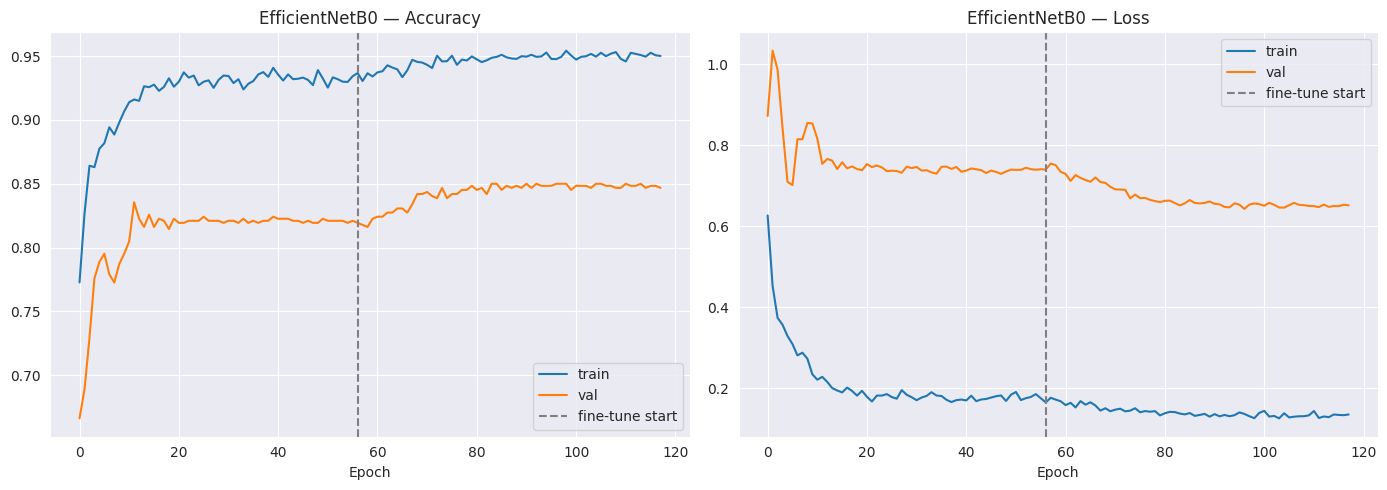

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(full_history["accuracy"], label="train")
axes[0].plot(full_history["val_accuracy"], label="val")
axes[0].axvline(phase1_len - 1, color="gray", linestyle="--", label="fine-tune start")
axes[0].set_title("EfficientNetB0 — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(full_history["loss"], label="train")
axes[1].plot(full_history["val_loss"], label="val")
axes[1].axvline(phase1_len - 1, color="gray", linestyle="--", label="fine-tune start")
axes[1].set_title("EfficientNetB0 — Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [14]:
test_loss, test_accuracy = model.evaluate(test_ds_oh)
print(f"Held-out test accuracy: {test_accuracy:.4f}")
print(f"Held-out test loss:     {test_loss:.4f}")


19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8569 - loss: 0.5684

2026-08-19 18:59:49.845345: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 18:59:49.980785: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 18:59:50.722674: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 18:59:50.858180: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 547ms/step - accuracy: 0.8801 - loss: 0.5397
Held-out test accuracy: 0.8801
Held-out test loss:     0.5397


In [15]:
y_true, y_pred, y_prob = [], [], []

for batch_x, batch_y in test_ds_oh:
    probs = model.predict(batch_x, verbose=0)
    y_prob.append(probs)
    y_pred.append(np.argmax(probs, axis=1))
    y_true.append(np.argmax(batch_y.numpy(), axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_prob = np.concatenate(y_prob)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

      glioma       0.94      0.78      0.85       190
  meningioma       0.87      0.79      0.83       145
     notumor       0.79      1.00      0.88        75
   pituitary       0.88      1.00      0.94       199

    accuracy                           0.88       609
   macro avg       0.87      0.89      0.87       609
weighted avg       0.89      0.88      0.88       609



In [16]:
# >>> AUTO-INSERTED: save test predictions for McNemar's test <<<
pred_df = pd.DataFrame({
    "filepath": test_df["filepath"].values,
    "y_true": y_true,
    "y_pred": y_pred,
})
pred_df.to_csv("efficientnetb0_test_predictions.csv", index=False)
print(f"Saved {len(pred_df)} predictions to efficientnetb0_test_predictions.csv")

Saved 609 predictions to efficientnetb0_test_predictions.csv


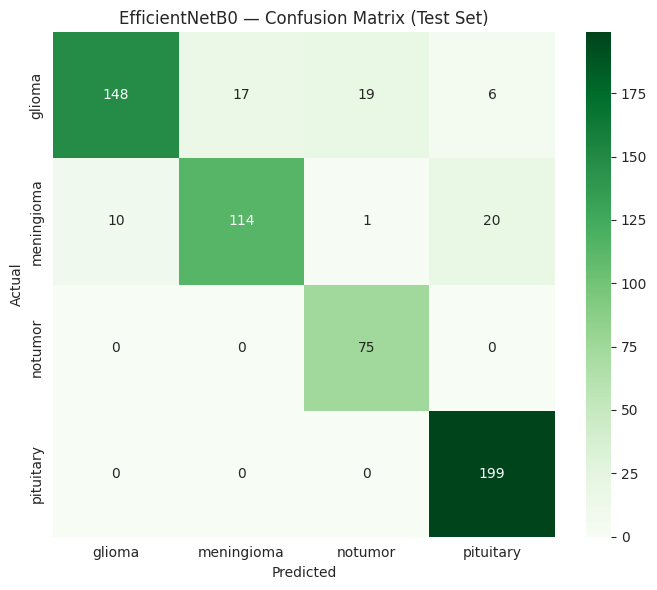

In [17]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


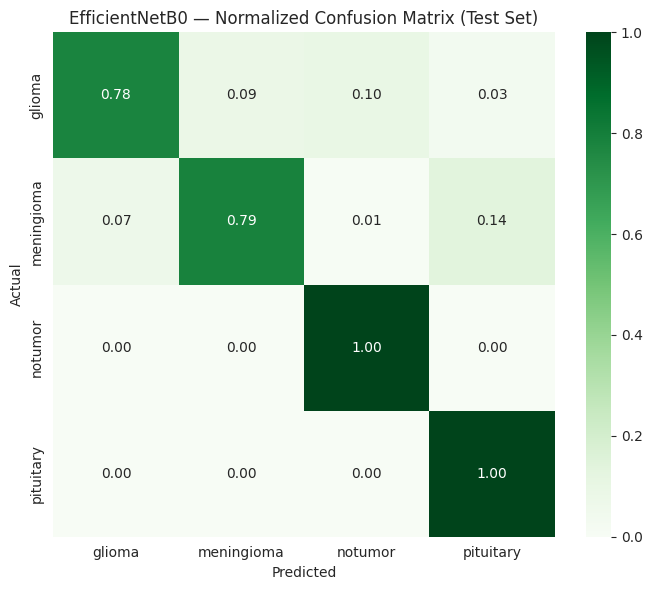

In [18]:
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Greens", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 — Normalized Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


## 9. Baseline Metrics Summary — Accuracy/F1, Model Size & Inference Time

To fairly compare CNN baselines against the graph-based model later, we log
more than accuracy: macro/weighted precision-recall-F1, per-class F1,
parameter counts, on-disk model size, and inference latency/throughput.

In [19]:
report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")

baseline_metrics = {
    "model_name": "EfficientNetB0_transfer",
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_macro,
    "recall_macro": recall_macro,
    "f1_macro": f1_macro,
    "precision_weighted": precision_weighted,
    "recall_weighted": recall_weighted,
    "f1_weighted": f1_weighted,
}
for cls in CLASS_NAMES:
    baseline_metrics[f"f1_{cls}"] = report_dict[cls]["f1-score"]

print("=== Classification Metrics Summary ===")
for k, v in baseline_metrics.items():
    print(f"{k:22s}: {v:.4f}" if isinstance(v, float) else f"{k:22s}: {v}")


=== Classification Metrics Summary ===
model_name            : EfficientNetB0_transfer
accuracy              : 0.8801
precision_macro       : 0.8702
recall_macro          : 0.8913
f1_macro              : 0.8744
precision_weighted    : 0.8857
recall_weighted       : 0.8801
f1_weighted           : 0.8774
f1_glioma             : 0.8506
f1_meningioma         : 0.8261
f1_notumor            : 0.8824
f1_pituitary          : 0.9387


In [20]:
# --- Model size ---
total_params = model.count_params()
trainable_params = int(sum(np.prod(w.shape) for w in model.trainable_weights))
non_trainable_params = total_params - trainable_params

size_probe_path = "efficientnetb0_size_probe.keras"
model.save(size_probe_path)
model_size_mb = os.path.getsize(size_probe_path) / (1024 ** 2)

baseline_metrics["total_params"] = int(total_params)
baseline_metrics["trainable_params"] = trainable_params
baseline_metrics["non_trainable_params"] = int(non_trainable_params)
baseline_metrics["model_size_mb"] = round(model_size_mb, 2)

print("=== Model Size ===")
print(f"Total params:         {total_params:,}")
print(f"Trainable params:     {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")
print(f"Saved model size:     {model_size_mb:.2f} MB")


=== Model Size ===
Total params:         4,597,927
Trainable params:     1,887,796
Non-trainable params: 2,710,131
Saved model size:     32.78 MB


In [21]:
# --- Inference time: single-image latency + batch throughput ---
sample_batch_x = next(iter(test_ds_oh))[0]

# Warm-up run (excludes graph tracing / XLA compilation overhead from timing)
_ = model.predict(sample_batch_x[:1], verbose=0)

N_SINGLE_RUNS = 30
single_image = sample_batch_x[:1]
start = time.perf_counter()
for _ in range(N_SINGLE_RUNS):
    _ = model.predict(single_image, verbose=0)
single_latency_ms = (time.perf_counter() - start) / N_SINGLE_RUNS * 1000

N_BATCH_RUNS = 5
batch_size_used = sample_batch_x.shape[0]
start = time.perf_counter()
for _ in range(N_BATCH_RUNS):
    _ = model.predict(sample_batch_x, verbose=0)
elapsed = time.perf_counter() - start
throughput_imgs_per_sec = (batch_size_used * N_BATCH_RUNS) / elapsed

baseline_metrics["inference_latency_ms_per_image"] = round(single_latency_ms, 3)
baseline_metrics["inference_throughput_imgs_per_sec"] = round(throughput_imgs_per_sec, 2)

print("=== Inference Time ===")
print(f"Single-image latency: {single_latency_ms:.3f} ms/image (avg over {N_SINGLE_RUNS} runs, batch_size=1)")
print(f"Batch throughput:     {throughput_imgs_per_sec:.2f} images/sec (batch_size={batch_size_used})")
print("\nNote: figures are hardware-dependent (GPU/CPU, batch size) — use the same")
print("hardware when comparing against the GCN model and other CNN baselines.")


=== Inference Time ===
Single-image latency: 82.332 ms/image (avg over 30 runs, batch_size=1)
Batch throughput:     253.56 images/sec (batch_size=32)

Note: figures are hardware-dependent (GPU/CPU, batch size) — use the same
hardware when comparing against the GCN model and other CNN baselines.


In [22]:
with open("efficientnetb0_baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)

metrics_df = pd.DataFrame([baseline_metrics])
metrics_df.to_csv("efficientnetb0_baseline_metrics.csv", index=False)
print("Saved efficientnetb0_baseline_metrics.json / .csv")
metrics_df.T


Saved efficientnetb0_baseline_metrics.json / .csv


,0
model_name,EfficientNetB0_transfer
accuracy,0.880131
precision_macro,0.870214
recall_macro,0.891289
f1_macro,0.874423
precision_weighted,0.88567
recall_weighted,0.880131
f1_weighted,0.877447
f1_glioma,0.850575
f1_meningioma,0.826087


## 10. Prediction Gallery

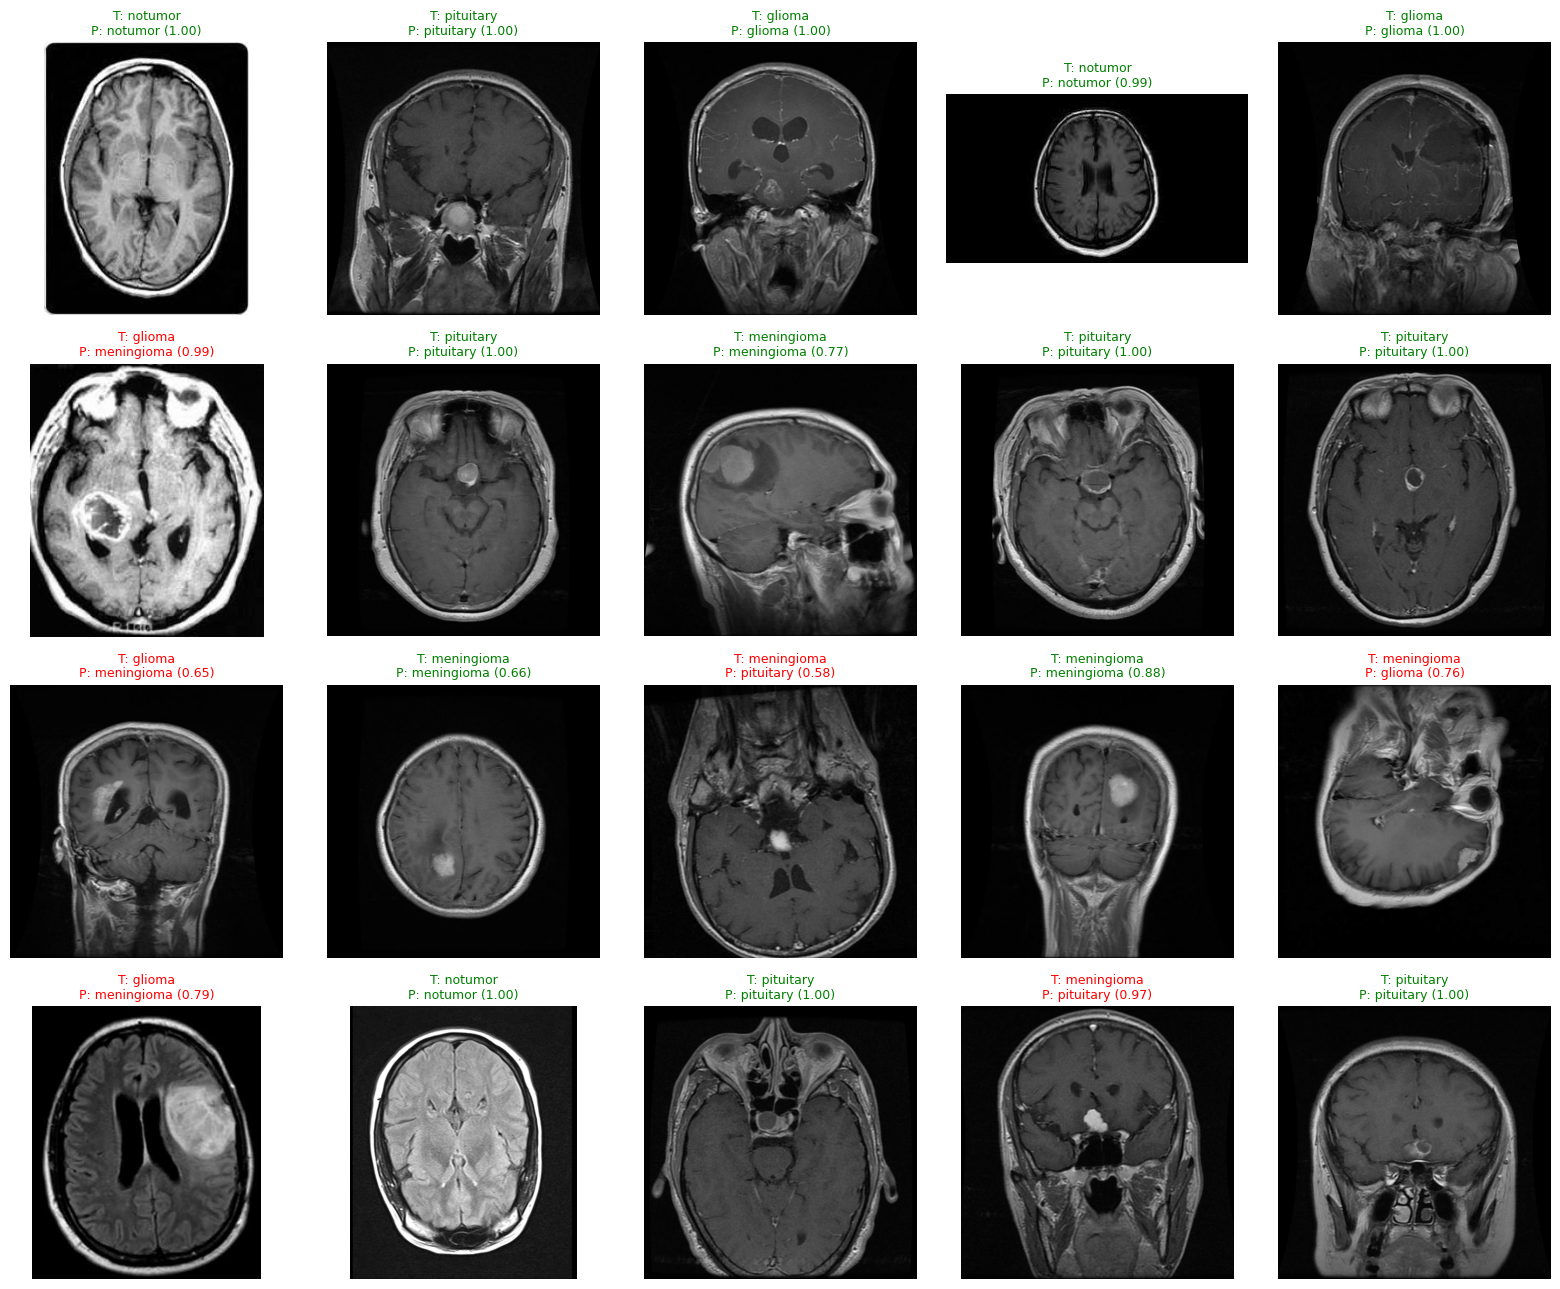

In [23]:
test_filepaths = test_df["filepath"].tolist()
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(test_filepaths), size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
for ax, idx in zip(axes.ravel(), sample_idx):
    fp = test_filepaths[idx]
    true_label = CLASS_NAMES[y_true[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    confidence = y_prob[idx][y_pred[idx]]

    img = Image.open(fp)
    ax.imshow(img, cmap="gray")
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"T: {true_label}\nP: {pred_label} ({confidence:.2f})", color=color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


Misclassified: 73 / 609 (12.0%)


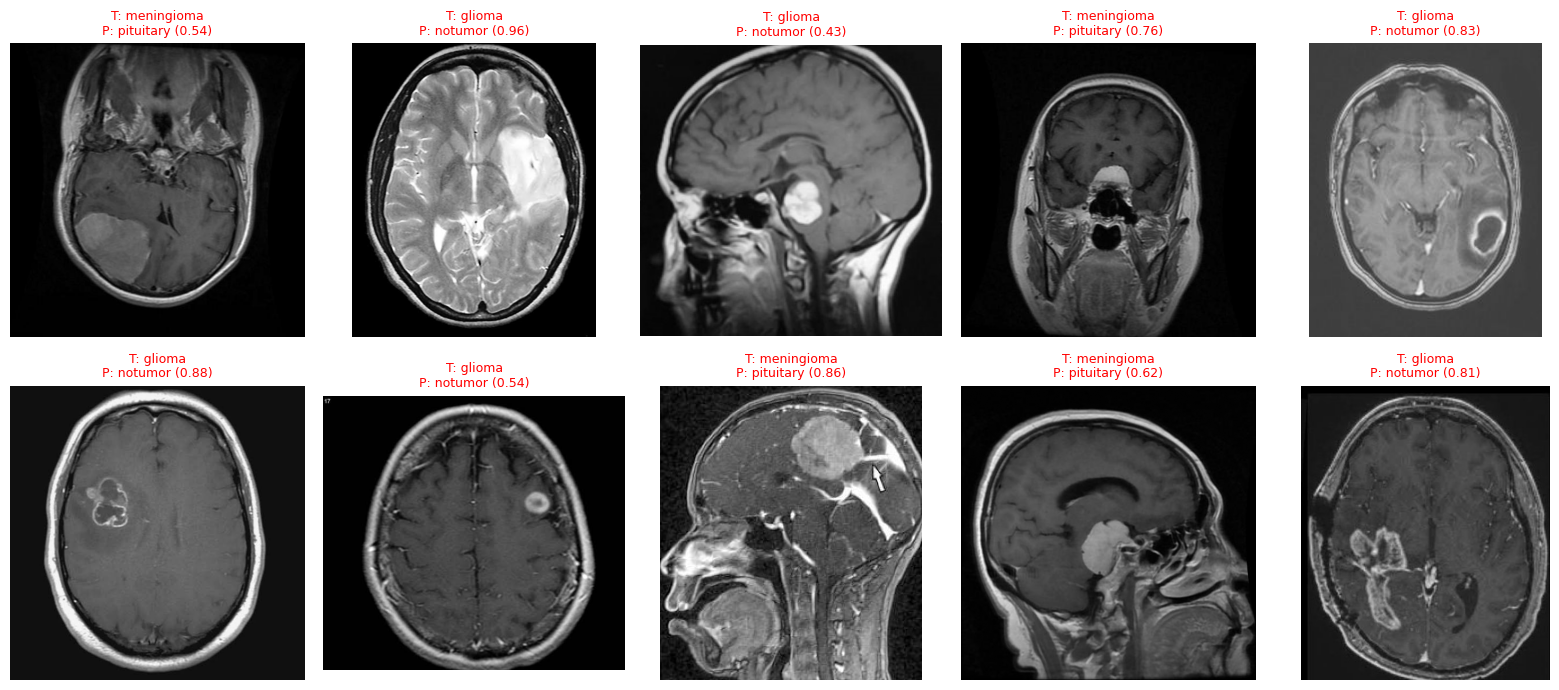

In [24]:
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Misclassified: {len(misclassified_idx)} / {len(y_true)} ({len(misclassified_idx)/len(y_true):.1%})")

n_show = min(10, len(misclassified_idx))
if n_show > 0:
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    for ax, idx in zip(axes.ravel(), misclassified_idx[:n_show]):
        fp = test_filepaths[idx]
        true_label = CLASS_NAMES[y_true[idx]]
        pred_label = CLASS_NAMES[y_pred[idx]]
        confidence = y_prob[idx][y_pred[idx]]
        img = Image.open(fp)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"T: {true_label}\nP: {pred_label} ({confidence:.2f})", color="red", fontsize=9)
        ax.axis("off")
    for ax in axes.ravel()[n_show:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 11. Save the Final Model

In [25]:
model.save("efficientnetb0_brain_tumor_final.keras")
print("Model saved to efficientnetb0_brain_tumor_final.keras")


Model saved to efficientnetb0_brain_tumor_final.keras


## Summary

- **Approach:** Transfer learning with EfficientNetB0 (ImageNet weights), a
  `tf.data` pipeline (decode → resize → augment → EfficientNet
  preprocessing), and a custom Dense/BatchNorm/Dropout head, trained in two
  phases — frozen-backbone head training, then fine-tuning the top ~20
  backbone layers (BatchNorm layers kept frozen) at a low learning rate.
- **Leakage check:** train/val/test splits are audited for exact (MD5) and
  near-duplicate (16x16 perceptual hash, with a class-mismatch sanity check to
  filter out hash false positives) images before training, matching the VGG16
  baseline's approach; any leaked rows are dropped from val/test, and val<->test
  duplicates are also checked and resolved, so held-out metrics aren't inflated.
- **Class imbalance:** handled via `sklearn`'s balanced class weights, passed
  to `model.fit(..., class_weight=...)` in both training phases.
- **Epoch policy:** each phase runs a minimum of 50 epochs (`start_from_epoch`)
  and a maximum of 100, with `EarlyStopping(patience=6, restore_best_weights=True)`
  on `val_loss`.
- **Reported metrics:** accuracy, macro/weighted precision/recall/F1,
  per-class F1, confusion matrix (raw + normalized), classification report,
  parameter counts, on-disk model size, and single-image / batch inference
  timing — all persisted to `efficientnetb0_baseline_metrics.json` / `.csv`
  for the CNN-vs-GCN comparison table.
